## Distributed Multi-Robot Formation Control in Dynamic Environments

The purpose of this algorithm is to present a *distributed* method for formation control of a team of robots
- Robots navigate around both static and dynamic obstacles

![image](../figures/image1.png)

![image](../figures/result.png)

https://www.youtube.com/watch?v=khzM54Qk1QQ

The algorithm can easily be broken up into 6 steps:
1. Hull Consensus
2. Preferred Direction of Motion
3. Intersection of Convex Regions
4. Formation Optimization
5. Slot Assignment
6. Motion

![flow](../figures/flow.png)

### Step 1: Convex Hull of Robot Positions

The robots create the convex hull $\mathcal{C}$ of their positions in a distributed algorithm:
1. Agent sends out its starting convex hull $\mathcal{C}_i(k)$, (which is really just the robot's starting position) to all of it's neighors
2. Agent then receives $\mathcal{C}_j(k) \quad j \in \mathcal{N}_i$
3. Compute the new updated convex hull $\mathcal{C}_i(k+1) =$ convexhull $(\mathcal{C}_i(k),\mathcal{C}_j(k))$
4. Do this for $d$ iterations, which is equal to the diameter of the communication graph $\mathcal{G}$

![Algorithm 1](../figures/algorithm11.png)

Robots : 5
Edges  : 5
Diameter: 2
Obstacles: 2


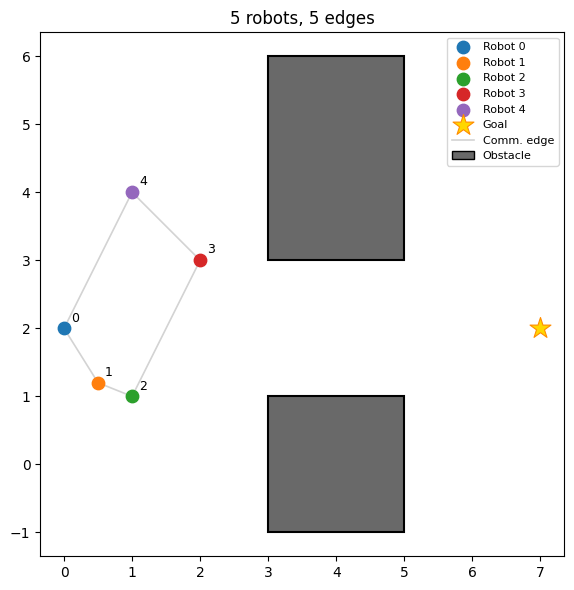

In [17]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from geometry.free_space import compute_local_free_region, visible_obstacles
from consensus.region_consensus import run_region_consensus as _run_consensus
from formation.templates import TEMPLATES
from formation.optimizer import optimize_formation
from formation.assignment import solve_assignment
from robots.dynamics import (
    step_double_integrator, compute_pd_acceleration,
    project_velocity, project_velocity_obstacles
)
from plotting.draw_team import draw_rect_obstacles, ROBOT_COLORS, draw_team_state
from plotting.draw_obstacles import draw_free_region
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

scenario = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

fig, ax = plt.subplots(figsize=(8, 6))
draw_rect_obstacles(ax, obstacles)
draw_team_state(ax, agents, adjacency, goal=goal)

d = graph_diameter(adjacency)
n_edges = int(adjacency.sum()) // 2
print(f"Robots : {len(agents)}")
print(f"Edges  : {n_edges}")
print(f"Diameter: {d}")
print(f"Obstacles: {len(obstacles)}")

plt.tight_layout()
plt.show()

Rounds run : 2
Converged  : True at round 2


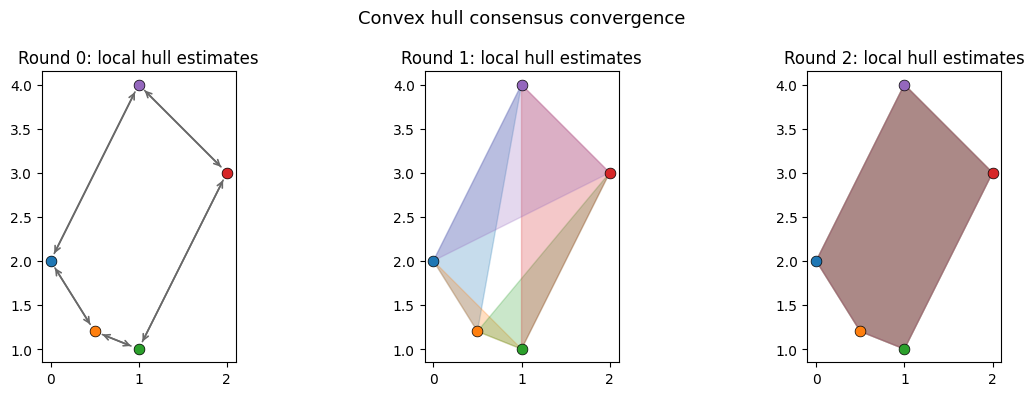

In [18]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus, did_hulls_converge
from plotting.draw_hulls import draw_hull_convergence_summary
import matplotlib.pyplot as plt
import numpy as np

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']

positions = np.array([a.position for a in agents])

num_rounds = graph_diameter(adjacency)

history = run_convex_hull_consensus(positions, adjacency, num_rounds)
converged, k = did_hulls_converge(history)
print(f"Rounds run : {num_rounds}")
print(f"Converged  : {converged} at round {k}")

fig = draw_hull_convergence_summary(history, positions, adjacency=adjacency)
plt.show()

### Step 2: Compute Preferred Direction of Motion

The agents must now decide in which direction they want to move.

The optimal direction of motion $\theta^*$, is a priori the angle of the vector from the centroid $\mathbf{c}$ of the convex hull $\mathcal{C}$ to the goal position $\mathbf{g}$

However, sometimes an obstacle is in the way of that direction, which might be seen by only a few of the robots in the swarm. So, the robots then must agree on the upon the best direction to go

To do come to a consensus the robots:
1. Have each agent compute the utility of each angle in a discreet set of angles $\Theta = \{\theta_1, ..... ,\theta_k\}$. i.e Utility is the distance to an obstacle in direction $\theta$
2. The utility of one angle $\theta$ is given by the worst utility among all the robots, since different robots can have different utility values for different angles. $u(\theta) = \min_{i \in \mathcal{I}} u_i(\theta)$
3. Therefore, the best direction of preferred motion is given by $\theta^* = \argmax_{\theta \in \Theta}\min_{i \in \mathcal{I}} u_i(\theta)$

![algorithm2](../figures/algorithm2.png)

Rounds run : 2
θ*         : 0.0°


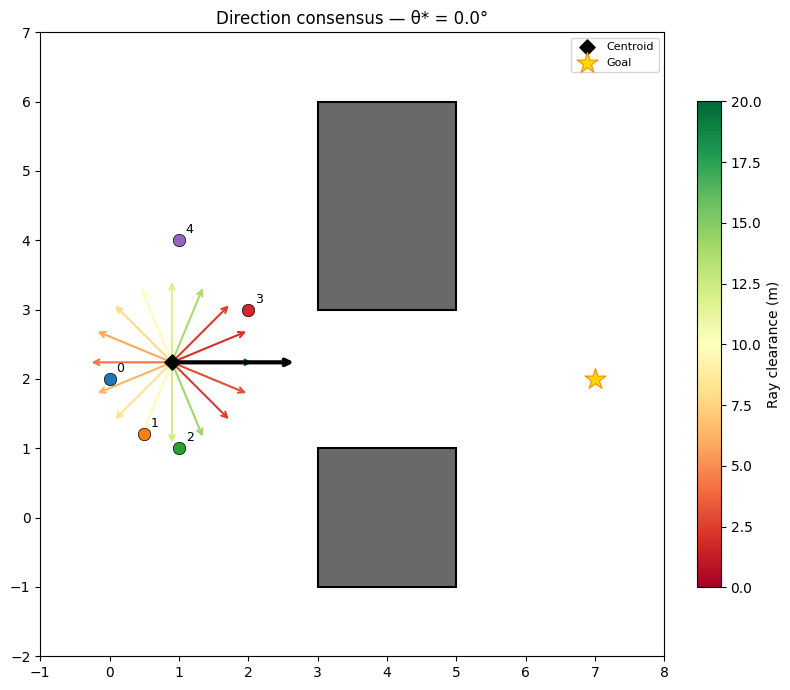

In [19]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from plotting.draw_team import draw_direction_result
import matplotlib.pyplot as plt
import numpy as np

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

positions  = np.array([a.position for a in agents])
num_rounds = graph_diameter(adjacency)

# Phase 1 result: hull centroid is the arrow origin
hull_history = run_convex_hull_consensus(positions, adjacency, num_rounds)
hull_vertices = hull_history[-1][0]          # all robots agree after d rounds
centroid = hull_vertices.mean(axis=0)

# 16 candidate angles evenly spaced around the full circle
candidate_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)

_, final_utilities = run_direction_consensus(
    positions, adjacency, obstacles, candidate_angles, num_rounds,
    centroid=centroid, goal=goal,
)

# All rows of final_utilities are identical after consensus — use robot 0's
theta_star = select_preferred_direction(final_utilities[0], candidate_angles)

print(f"Rounds run : {num_rounds}")
print(f"θ*         : {np.degrees(theta_star):.1f}°")

fig, ax = plt.subplots(figsize=(9, 7))
draw_direction_result(ax, agents, obstacles, centroid,
                        candidate_angles, final_utilities[0], theta_star,
                        goal=goal)
plt.tight_layout()
plt.show()


### 3. Obstacle-free Convex Region

Now the robots all have a shared convex hull $\mathcal{C}$ and a preferred direction of motion. 

The swarm now seeks to find an obstacle-free convex region that it can take it's formation in. This is done by having each robot compute TWO different convex regions
1. $\mathcal{P}_i^\mathcal{C}$ which is a region computed in the direction of $\theta^*$, but contains the entire convex hull $\mathcal{C}$
2. $\mathcal{P}_i^\mathbf{c}$ which is another region computed in the direction of $\theta^*$, but only contains the cenroid $\mathbf{c}$

![open sets](../figures/sets.png)

It is the intersection of these two regions $\mathcal{P}_i = \mathcal{P}_i^\mathcal{C} \cap \mathcal{P}_i^\mathbf{c}$ that the swarm will seek to move its formation into. However, each robot has a different limited field of view, and cannot see all obstacles.

So, robots must perform consensus on on obstacle-free convex region to find $\mathcal{P} = \cap_{i \in \mathcal{I}} \mathcal{P}_i$

![alg3](../figures/alg3.png)


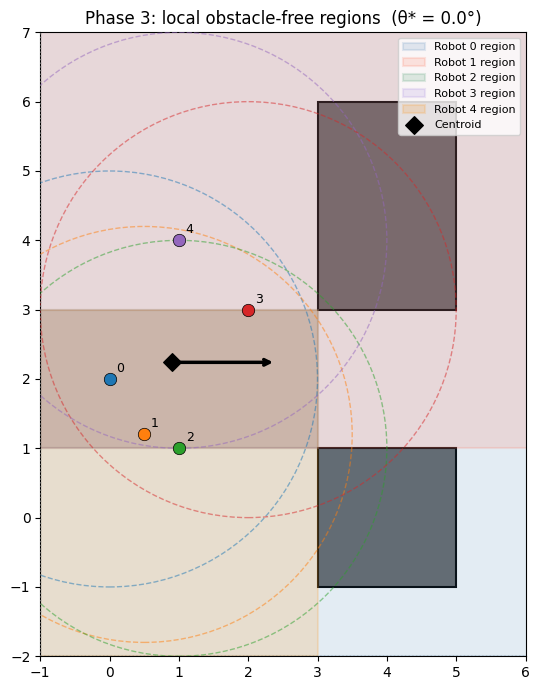

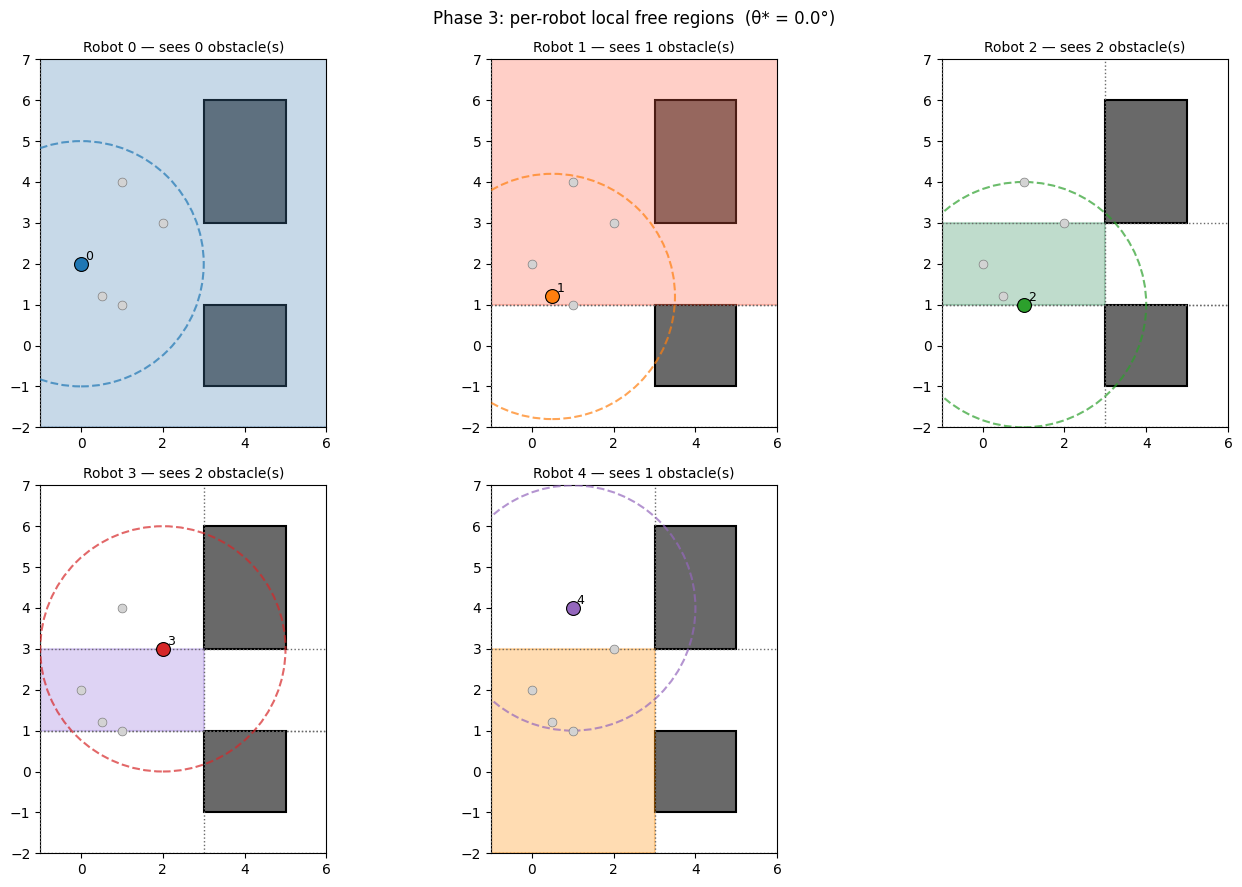

Rounds     : 2
θ*         : 0.0°
Centroid   : [0.9  2.24]
Robot 0: sees 0 obstacle(s), 4 half-space constraints
Robot 1: sees 1 obstacle(s), 6 half-space constraints
Robot 2: sees 2 obstacle(s), 8 half-space constraints
Robot 3: sees 2 obstacle(s), 8 half-space constraints
Robot 4: sees 1 obstacle(s), 6 half-space constraints


In [20]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from geometry.free_space import compute_local_free_region, visible_obstacles
from plotting.draw_team import draw_rect_obstacles, ROBOT_COLORS
from plotting.draw_obstacles import draw_free_region, draw_halfspace_boundaries
import matplotlib.pyplot as plt
import numpy as np

REGION_COLORS = ['steelblue', 'tomato', 'seagreen', 'mediumpurple', 'darkorange']

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

positions  = np.array([a.position for a in agents])
num_rounds = graph_diameter(adjacency)

# Phase 1 — hull centroid
hull_history  = run_convex_hull_consensus(positions, adjacency, num_rounds)
hull_vertices = hull_history[-1][0]
centroid      = hull_vertices.mean(axis=0)

# Phase 2 — preferred direction
candidate_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
_, final_utilities = run_direction_consensus(
    positions, adjacency, obstacles, candidate_angles, num_rounds,
    centroid=centroid, goal=goal,
)
theta_star = select_preferred_direction(final_utilities[0], candidate_angles)

# Phase 3 — each robot's local free region (based on what it can see)
fig, ax = plt.subplots(figsize=(9, 7))
draw_rect_obstacles(ax, obstacles)

tau = 3.0  # look-ahead distance for computing χ = c + τ·[cos θ*, sin θ*]
local_obstacle_lists = [
    visible_obstacles(agent.position, obstacles, agent.sensing_range)
    for agent in agents
]

for i, agent in enumerate(agents):
    A, b = compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[i],
                                        theta_star=theta_star, tau=tau)
    draw_free_region(ax, A, b,
                        color=REGION_COLORS[i % len(REGION_COLORS)],
                        alpha=0.15,
                        label=f"Robot {i} region")

# Robot positions, sensing circles, and id labels
for agent in agents:
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    # Sensing range circle — dashed, same color as robot
    circle = plt.Circle(agent.position, agent.sensing_range,
                        color=color, fill=False, linestyle='--',
                        linewidth=1.0, alpha=0.5, zorder=3)
    ax.add_patch(circle)
    ax.scatter(agent.position[0], agent.position[1],
                color=color, s=80, zorder=5, edgecolors='black', linewidths=0.5)
    ax.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
            str(agent.id), fontsize=9, zorder=6)

# Centroid and preferred direction arrow
ax.scatter(centroid[0], centroid[1], color='black', s=80,
            marker='D', zorder=6, label='Centroid')
tip = centroid + 1.5 * np.array([np.cos(theta_star), np.sin(theta_star)])
ax.annotate("", xy=tip, xytext=centroid,
            arrowprops=dict(arrowstyle='->', color='black', lw=2.5), zorder=6)

# Axis limits to show full scenario
all_x = list(positions[:, 0]) + [o.x_min for o in obstacles] + [o.x_max for o in obstacles]
all_y = list(positions[:, 1]) + [o.y_min for o in obstacles] + [o.y_max for o in obstacles]
margin = 1.0
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

# Draw half-space boundary lines for agent 0 only
A0, b0 = compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[0],
                                    theta_star=theta_star, tau=tau)
draw_halfspace_boundaries(ax, A0, b0)

ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_title(f"Phase 3: local obstacle-free regions  (θ* = {np.degrees(theta_star):.1f}°)")
plt.tight_layout()

# --- Per-robot figure: one panel per robot ---
fig2, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# Consistent axis limits across all panels
margin = 1.0
x_lo = min(all_x) - margin
x_hi = max(all_x) + margin
y_lo = min(all_y) - margin
y_hi = max(all_y) + margin

for i, agent in enumerate(agents):
    panel = axes[i]
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    region_color = REGION_COLORS[i % len(REGION_COLORS)]

    # Obstacles
    draw_rect_obstacles(panel, obstacles)

    # Free region for this robot
    A, b = compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[i],
                                        theta_star=theta_star, tau=tau)
    draw_free_region(panel, A, b, color=region_color, alpha=0.3)

    # Half-space boundary lines
    panel.set_xlim(x_lo, x_hi)
    panel.set_ylim(y_lo, y_hi)
    draw_halfspace_boundaries(panel, A, b)

    # Sensing circle
    circle = plt.Circle(agent.position, agent.sensing_range,
                            color=color, fill=False, linestyle='--',
                            linewidth=1.5, alpha=0.7, zorder=4)
    panel.add_patch(circle)

    # Other robots as small grey dots
    for other in agents:
        if other.id != agent.id:
            panel.scatter(other.position[0], other.position[1],
                            color='lightgrey', s=40, zorder=4,
                            edgecolors='grey', linewidths=0.5)

    # This robot as a large colored dot
    panel.scatter(agent.position[0], agent.position[1],
                    color=color, s=100, zorder=5,
                    edgecolors='black', linewidths=0.8)
    panel.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
                str(agent.id), fontsize=9, zorder=6)

    n_seen = len(local_obstacle_lists[i])
    panel.set_aspect('equal')
    panel.set_title(f"Robot {i} — sees {n_seen} obstacle(s)", fontsize=10)

# Hide the unused 6th panel
axes[-1].set_visible(False)

fig2.suptitle(f"Phase 3: per-robot local free regions  (θ* = {np.degrees(theta_star):.1f}°)",
                fontsize=12)
plt.tight_layout()
plt.show()

print(f"Rounds     : {num_rounds}")
print(f"θ*         : {np.degrees(theta_star):.1f}°")
print(f"Centroid   : {centroid}")
for i, agent in enumerate(agents):
    seen = local_obstacle_lists[i]
    A, b = compute_local_free_region(centroid, hull_vertices, seen, theta_star=theta_star, tau=tau)
    print(f"Robot {i}: sees {len(seen)} obstacle(s), {A.shape[0]} half-space constraints")

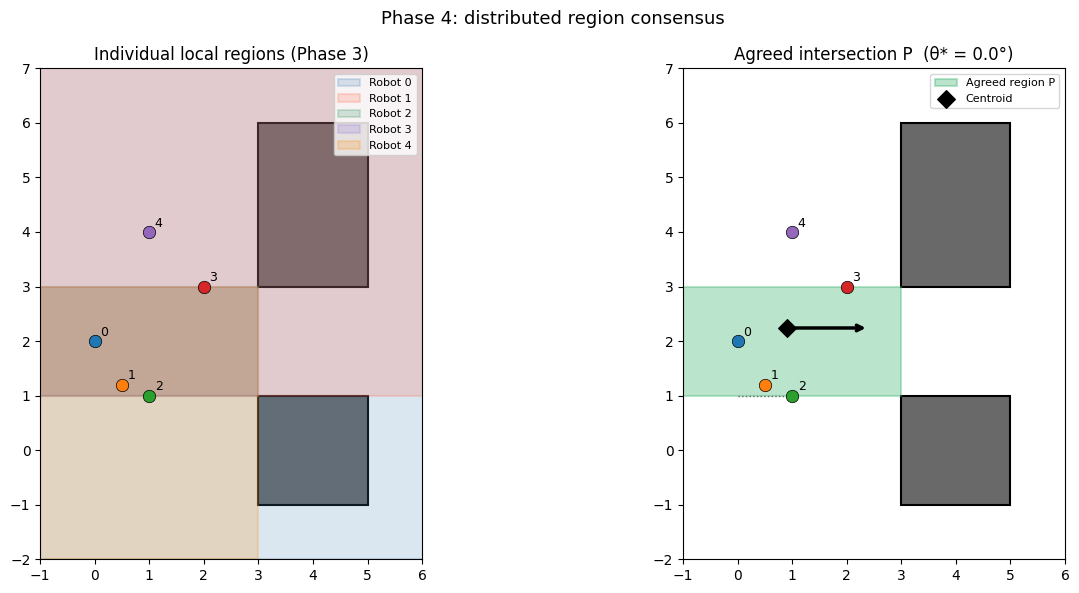

Rounds          : 2
θ*              : 0.0°
Agreed region   : 7 half-space constraints
  Robot 0: 4 constraints  (sees 0 obstacle(s))
  Robot 1: 6 constraints  (sees 1 obstacle(s))
  Robot 2: 8 constraints  (sees 2 obstacle(s))
  Robot 3: 8 constraints  (sees 2 obstacle(s))
  Robot 4: 6 constraints  (sees 1 obstacle(s))


In [21]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from geometry.free_space import compute_local_free_region, visible_obstacles
from consensus.region_consensus import run_region_consensus as _run_consensus
from plotting.draw_team import draw_rect_obstacles, ROBOT_COLORS
from plotting.draw_obstacles import draw_free_region, draw_halfspace_boundaries
import matplotlib.pyplot as plt
import numpy as np

REGION_COLORS = ['steelblue', 'tomato', 'seagreen', 'mediumpurple', 'darkorange']

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

positions  = np.array([a.position for a in agents])
num_rounds = graph_diameter(adjacency)

# Phase 1 — hull centroid
hull_history  = run_convex_hull_consensus(positions, adjacency, num_rounds)
hull_vertices = hull_history[-1][0]
centroid      = hull_vertices.mean(axis=0)

# Phase 2 — preferred direction
candidate_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
_, final_utilities = run_direction_consensus(
    positions, adjacency, obstacles, candidate_angles, num_rounds,
    centroid=centroid, goal=goal,
)
theta_star = select_preferred_direction(final_utilities[0], candidate_angles)

# Phase 3 — per-robot local free regions
tau = 3.0
local_obstacle_lists = [
    visible_obstacles(agent.position, obstacles, agent.sensing_range)
    for agent in agents
]
local_regions = [
    compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[i],
                                theta_star=theta_star, tau=tau)
    for i in range(len(agents))
]

# Phase 4 — consensus to intersect all local regions
_, (A_agreed, b_agreed) = _run_consensus(local_regions, adjacency, num_rounds)

# --- Plot ---
fig, (ax_ind, ax_agreed) = plt.subplots(1, 2, figsize=(14, 6))

# Left: individual regions
draw_rect_obstacles(ax_ind, obstacles)
for i, (A, b) in enumerate(local_regions):
    draw_free_region(ax_ind, A, b,
                        color=REGION_COLORS[i % len(REGION_COLORS)],
                        alpha=0.2, label=f"Robot {i}")
for agent in agents:
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    ax_ind.scatter(agent.position[0], agent.position[1],
                    color=color, s=80, zorder=5,
                    edgecolors='black', linewidths=0.5)
    ax_ind.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
                str(agent.id), fontsize=9, zorder=6)
ax_ind.set_aspect('equal')
ax_ind.legend(loc='upper right', fontsize=8)
ax_ind.set_title("Individual local regions (Phase 3)")

# Right: agreed intersection
draw_rect_obstacles(ax_agreed, obstacles)
draw_free_region(ax_agreed, A_agreed, b_agreed,
                    color='mediumseagreen', alpha=0.35, label='Agreed region P')
draw_halfspace_boundaries(ax_agreed, A_agreed, b_agreed)
for agent in agents:
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    ax_agreed.scatter(agent.position[0], agent.position[1],
                        color=color, s=80, zorder=5,
                        edgecolors='black', linewidths=0.5)
    ax_agreed.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
                    str(agent.id), fontsize=9, zorder=6)
ax_agreed.scatter(centroid[0], centroid[1], color='black', s=80,
                    marker='D', zorder=6, label='Centroid')
tip = centroid + 1.5 * np.array([np.cos(theta_star), np.sin(theta_star)])
ax_agreed.annotate("", xy=tip, xytext=centroid,
                    arrowprops=dict(arrowstyle='->', color='black', lw=2.5), zorder=6)
ax_agreed.set_aspect('equal')
ax_agreed.legend(loc='upper right', fontsize=8)
ax_agreed.set_title(f"Agreed intersection P  (θ* = {np.degrees(theta_star):.1f}°)")

# Shared axis limits
all_x = list(positions[:, 0]) + [o.x_min for o in obstacles] + [o.x_max for o in obstacles]
all_y = list(positions[:, 1]) + [o.y_min for o in obstacles] + [o.y_max for o in obstacles]
margin = 1.0
for ax in (ax_ind, ax_agreed):
    ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
    ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

plt.suptitle("Phase 4: distributed region consensus", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Rounds          : {num_rounds}")
print(f"θ*              : {np.degrees(theta_star):.1f}°")
print(f"Agreed region   : {A_agreed.shape[0]} half-space constraints")
for i in range(len(agents)):
    print(f"  Robot {i}: {local_regions[i][0].shape[0]} constraints  "
            f"(sees {len(local_obstacle_lists[i])} obstacle(s))")

### 4. Optimal Formation

Now that all robots agree on a shared obstacle-free region $\mathcal{P}$, the swarm must find the best formation to take inside it.

A formation is defined by a **template** — a set of $N$ unit-scale offset vectors $\{r_1, \ldots, r_N\}$ describing the shape (e.g. a pentagon or a line). The actual slot positions are then:

$$p_i^* = \mathbf{c} + s \cdot R(\phi) \cdot r_i$$

where $\mathbf{c}$ is the formation center, $s > 0$ is the scale, and $R(\phi)$ is a rotation matrix. The goal is to find the **largest** formation of that shape that fits inside $\mathcal{P}$, i.e. maximize $s$ subject to every slot lying inside the region:

$$A p_i^* \leq b \quad \forall i$$

Since rotating the template makes the problem non-convex in $\phi$, the rotation is **discretized**: a fixed set of candidate angles is tried, and for each fixed $\phi$ the problem reduces to a **linear program** in $(\mathbf{c},\ s)$:

$$\max_{\mathbf{c},\ s \geq 0} \quad s \qquad \text{subject to} \quad A\mathbf{c} + s\left(A R(\phi) r_i\right) \leq b \quad \forall i$$

The rotation that yields the largest feasible $s$ is kept, and the corresponding slot positions $\{p_i^*\}$ are the formation targets.

![formation](../figures/formation%20diagram.png)

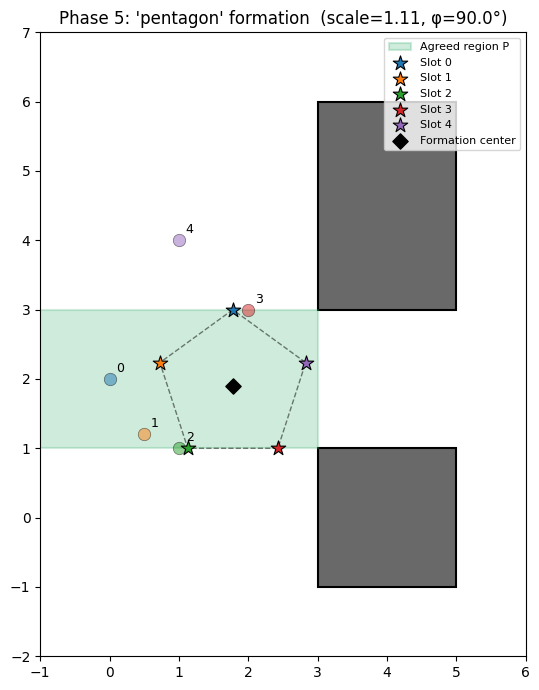

Template        : pentagon
Optimal scale   : 1.106
Optimal angle   : 90.0°
Formation center: [1.77798229 1.89442719]
Slot positions:
  Slot 0: [1.77798229 3.        ]
  Slot 1: [0.72652006 2.23606798]
  Slot 2: [1.12814289 1.        ]
  Slot 3: [2.42782168 1.        ]
  Slot 4: [2.82944451 2.23606798]


In [22]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from geometry.free_space import compute_local_free_region, visible_obstacles
from consensus.region_consensus import run_region_consensus as _run_consensus
from formation.templates import TEMPLATES
from formation.optimizer import optimize_formation
from plotting.draw_team import draw_rect_obstacles, ROBOT_COLORS
from plotting.draw_obstacles import draw_free_region, draw_halfspace_boundaries
import matplotlib.pyplot as plt
import numpy as np

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

positions  = np.array([a.position for a in agents])
num_rounds = graph_diameter(adjacency)

# Phase 1 — hull centroid
hull_history  = run_convex_hull_consensus(positions, adjacency, num_rounds)
hull_vertices = hull_history[-1][0]
centroid      = hull_vertices.mean(axis=0)

# Phase 2 — preferred direction
candidate_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
_, final_utilities = run_direction_consensus(
    positions, adjacency, obstacles, candidate_angles, num_rounds,
    centroid=centroid, goal=goal,
)
theta_star = select_preferred_direction(final_utilities[0], candidate_angles)

# Phase 3 — per-robot local free regions
tau = 3.0
local_obstacle_lists = [
    visible_obstacles(agent.position, obstacles, agent.sensing_range)
    for agent in agents
]
local_regions = [
    compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[i],
                                theta_star=theta_star, tau=tau)
    for i in range(len(agents))
]

# Phase 4 — agreed intersection
_, (A_agreed, b_agreed) = _run_consensus(local_regions, adjacency, num_rounds)

# Phase 5 — optimize formation template inside agreed region
template_name = 'pentagon'
template = TEMPLATES[template_name]
result = optimize_formation(A_agreed, b_agreed, template, theta_star)

if result is None:
    print("No feasible formation found inside the agreed region.")
    

best_center, best_scale, best_angle, slots = result

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 7))
draw_rect_obstacles(ax, obstacles)

# Agreed region
draw_free_region(ax, A_agreed, b_agreed,
                    color='mediumseagreen', alpha=0.25, label='Agreed region P')

# Formation slot positions — colored by robot id, connected by lines
slot_colors = [ROBOT_COLORS[i % len(ROBOT_COLORS)] for i in range(len(slots))]
for i, slot in enumerate(slots):
    ax.scatter(slot[0], slot[1], color=slot_colors[i], s=120,
                zorder=6, edgecolors='black', linewidths=0.8,
                marker='*', label=f"Slot {i}")
# Close the formation polygon
loop = np.vstack([slots, slots[0]])
ax.plot(loop[:, 0], loop[:, 1], 'k--', linewidth=1.0, alpha=0.5, zorder=5)

# Formation center
ax.scatter(best_center[0], best_center[1], color='black', s=60,
            marker='D', zorder=7, label='Formation center')

# Current robot positions
for agent in agents:
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    ax.scatter(agent.position[0], agent.position[1],
                color=color, s=80, zorder=5,
                edgecolors='black', linewidths=0.5, alpha=0.5)
    ax.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
            str(agent.id), fontsize=9, zorder=6)

# Preferred direction arrow from centroid
# tip = centroid + 1.5 * np.array([np.cos(theta_star), np.sin(theta_star)])
# ax.annotate("", xy=tip, xytext=centroid,
#             arrowprops=dict(arrowstyle='->', color='black', lw=2.5), zorder=6)

# Goal marker
#ax.scatter(goal[0], goal[1], marker='*', s=250, color='gold',
            #edgecolors='darkorange', linewidths=0.8, zorder=6, label='Goal')

all_x = list(positions[:, 0]) + [o.x_min for o in obstacles] + [o.x_max for o in obstacles]
all_y = list(positions[:, 1]) + [o.y_min for o in obstacles] + [o.y_max for o in obstacles]
margin = 1.0
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_title(
    f"Phase 5: '{template_name}' formation  "
    f"(scale={best_scale:.2f}, φ={np.degrees(best_angle):.1f}°)"
)
plt.tight_layout()
plt.show()

print(f"Template        : {template_name}")
print(f"Optimal scale   : {best_scale:.3f}")
print(f"Optimal angle   : {np.degrees(best_angle):.1f}°")
print(f"Formation center: {best_center}")
print("Slot positions:")
for i, slot in enumerate(slots):
    print(f"  Slot {i}: {slot}")

### Step 5. Slot Assignment

Robots are assigned to the goal positions with the objective of minimizing the sum of the squarred travelled distances. So we want to find the permutation matrix $\mathcal{X}$ such that

$$\min_{\mathcal{X}} \sum_{i \in \mathcal{I}}\sum_{j \in \mathcal{I}} \mathcal{x}_{ij} ||\mathbf{p}_i - \mathbf{r}_j^*|| ^2$$

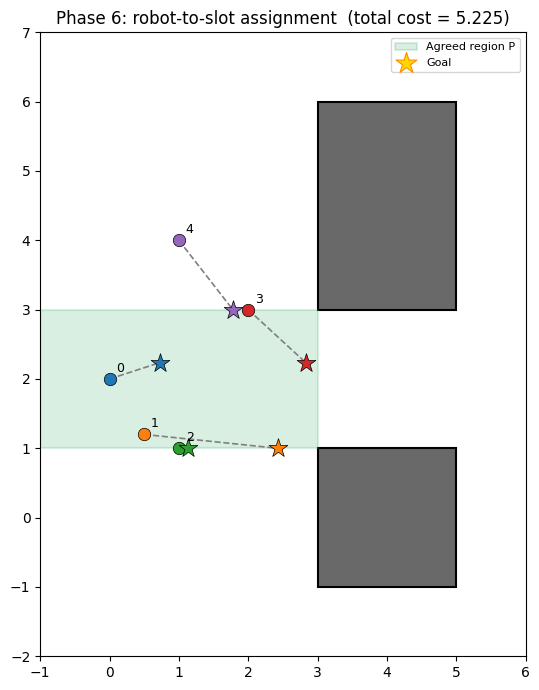

Template     : pentagon
Total cost   : 5.225
  Robot 0 → Slot 1  (dist = 0.764)
  Robot 1 → Slot 3  (dist = 1.938)
  Robot 2 → Slot 2  (dist = 0.128)
  Robot 3 → Slot 4  (dist = 1.128)
  Robot 4 → Slot 0  (dist = 1.267)


In [23]:
from simulation.scenario import create_default_scenario
from consensus.graph_utils import graph_diameter
from consensus.convex_hull import run_convex_hull_consensus
from consensus.preferred_direction import (
    run_direction_consensus, select_preferred_direction
)
from geometry.free_space import compute_local_free_region, visible_obstacles
from consensus.region_consensus import run_region_consensus as _run_consensus
from formation.templates import TEMPLATES
from formation.optimizer import optimize_formation
from formation.assignment import solve_assignment
from plotting.draw_team import draw_rect_obstacles, ROBOT_COLORS
from plotting.draw_obstacles import draw_free_region
import matplotlib.pyplot as plt
import numpy as np

scenario  = create_default_scenario()
agents    = scenario['agents']
adjacency = scenario['adjacency']
obstacles = scenario['obstacles']
goal      = scenario['goal']

positions  = np.array([a.position for a in agents])
num_rounds = graph_diameter(adjacency)

# Phases 1–4
hull_history  = run_convex_hull_consensus(positions, adjacency, num_rounds)
hull_vertices = hull_history[-1][0]
centroid      = hull_vertices.mean(axis=0)

candidate_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
_, final_utilities = run_direction_consensus(
    positions, adjacency, obstacles, candidate_angles, num_rounds,
    centroid=centroid, goal=goal,
)
theta_star = select_preferred_direction(final_utilities[0], candidate_angles)

tau = 3.0
local_obstacle_lists = [
    visible_obstacles(agent.position, obstacles, agent.sensing_range)
    for agent in agents
]
local_regions = [
    compute_local_free_region(centroid, hull_vertices, local_obstacle_lists[i],
                                theta_star=theta_star, tau=tau)
    for i in range(len(agents))
]
_, (A_agreed, b_agreed) = _run_consensus(local_regions, adjacency, num_rounds)

# Phase 5 — formation optimization
template_name = 'pentagon'
template = TEMPLATES[template_name]
result = optimize_formation(A_agreed, b_agreed, template, theta_star)
if result is None:
    print("No feasible formation found.")
_, _, _, slots = result

# Phase 6 — assignment
assignment, total_cost = solve_assignment(positions, slots)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 7))
draw_rect_obstacles(ax, obstacles)
draw_free_region(ax, A_agreed, b_agreed,
                    color='mediumseagreen', alpha=0.2, label='Agreed region P')

# Assignment lines
for i, agent in enumerate(agents):
    slot_idx = assignment[i]
    ax.plot([agent.position[0], slots[slot_idx, 0]],
            [agent.position[1], slots[slot_idx, 1]],
            color='grey', linewidth=1.2, linestyle='--', zorder=3)

# Slot positions
for j, slot in enumerate(slots):
    ax.scatter(slot[0], slot[1], marker='*', s=200, zorder=6,
                color=ROBOT_COLORS[assignment.tolist().index(j) % len(ROBOT_COLORS)],
                edgecolors='black', linewidths=0.5)

# Robot positions
for i, agent in enumerate(agents):
    color = ROBOT_COLORS[agent.id % len(ROBOT_COLORS)]
    ax.scatter(agent.position[0], agent.position[1],
                color=color, s=80, zorder=5,
                edgecolors='black', linewidths=0.5)
    ax.text(agent.position[0] + 0.1, agent.position[1] + 0.1,
            str(agent.id), fontsize=9, zorder=7)

# Goal
ax.scatter(goal[0], goal[1], marker='*', s=250, color='gold',
            edgecolors='darkorange', linewidths=0.8, zorder=6, label='Goal')

all_x = list(positions[:, 0]) + [o.x_min for o in obstacles] + [o.x_max for o in obstacles]
all_y = list(positions[:, 1]) + [o.y_min for o in obstacles] + [o.y_max for o in obstacles]
margin = 1.0
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_title(f"Phase 6: robot-to-slot assignment  (total cost = {total_cost:.3f})")
plt.tight_layout()
plt.show()

print(f"Template     : {template_name}")
print(f"Total cost   : {total_cost:.3f}")
for i in range(len(agents)):
    print(f"  Robot {i} → Slot {assignment[i]}  "
            f"(dist = {np.linalg.norm(positions[i] - slots[assignment[i]]):.3f})")

### Step 6. Motion

Robots are now able to move in straight lines toward their assigned spot. Because of the convex free spaces they calculated earlier, straight line paths are obstacle-free.